#  4章　データ分析実践編
タイタニック・データセットを用いた分析


## 共通処理

In [8]:
# 日本語化ライブラリ導入
!pip install japanize-matplotlib | tail -n 1

In [9]:
# ライブラリのimport

# NumPy用ライブラリ
import numpy as np

# Matplotlib中のpyplotライブラリのインポート
import matplotlib.pyplot as plt

# matplotlib日本語化対応ライブラリのインポート
import japanize_matplotlib

# pandas用ライブラリ
import pandas as pd

# データフレーム表示用関数
from IPython.display import display

# seaborn
import seaborn as sns

In [10]:
# 表示オプション調整

# NumPy表示形式の設定
np.set_printoptions(
    suppress=True, precision=4, floatmode='fixed'
)

# グラフのデフォルトフォント指定
plt.rcParams["font.size"] = 14

# サイズ設定
plt.rcParams['figure.figsize'] = (6, 6)

# 方眼表示ON
plt.rcParams['axes.grid'] = True

# データフレームでの表示精度
pd.options.display.float_format = '{:.4f}'.format

# データフレームですべての項目を表示
pd.set_option("display.max_columns",None)

##  4.2 データ読み込み

### ファイルダウンロード

In [11]:
url = 'https://raw.githubusercontent.com/makaishi2/samples/main/data/titanic-v2.csv'
!wget $url

--2026-04-28 01:52:42--  https://raw.githubusercontent.com/makaishi2/samples/main/data/titanic-v2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109153 (107K) [text/plain]
Saving to: ‘titanic-v2.csv.1’

titanic-v2.csv.1    100%[===================>] 106.59K  --.-KB/s    in 0.002s  

2026-04-28 01:52:42 (43.6 MB/s) - ‘titanic-v2.csv.1’ saved [109153/109153]



### ファイル内容確認

In [12]:
# ファイル名の定義
csv_fn = 'titanic-v2.csv'

# 先頭を確認
!head -3 $csv_fn

pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1,1,'Allen, Miss. Elisabeth Walton',female,29,0,0,24160,211.3375,B5,S,2,?,'St Louis, MO'
1,1,'Allison, Master. Hudson Trevor',male,0.9167,1,2,113781,151.55,'C22 C26',S,11,?,'Montreal, PQ / Chesterville, ON'


### データ読み込み　その1

In [13]:
df = pd.read_csv(
    csv_fn,
    na_values='?',
    quotechar="'",
    escapechar='\\')


### 問題判別

In [14]:
# 問題の起きた行を確認
!head -130 $csv_fn | tail -1

1,0,'Gee, Mr. Arthur H',male,47,0,0,111320,38.5,E63,S,?,275,'St Anne\'s-on-Sea, Lancashire'


### データ読み込み　その２

In [15]:
# データ読み込み　その2
df = pd.read_csv(
    csv_fn,
    na_values = '?',
    quotechar = "'",
    escapechar = '\\')

# 結果確認
display(df.head(1))

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"


## 4.3 データ確認・加工

### データ型確認


In [16]:
# データ型確認(3.3.4項)
df.dtypes

,0
pclass,int64
survived,int64
name,object
sex,object
age,float64
sibsp,int64
parch,int64
ticket,object
fare,float64
cabin,object


In [17]:
# 項目bodyの一部を表示
df[['body']].head()

,body
0,NaN
1,NaN
2,NaN
3,135.0000
4,NaN


### 3度目のデータ読み込み

In [18]:
# 3度目のデータ読み込み
df = pd.read_csv(
    csv_fn,
    na_values = '?',
    quotechar = "'",
    escapechar = '\\',
    # 項目bodyを文字列型として読み込むよう指定
    dtype = {'body': object})

# 結果確認(データ型)
print(df.dtypes)

pclass         int64
survived       int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
cabin         object
embarked      object
boat          object
body          object
home.dest     object
dtype: object


In [19]:
# 項目bodyの先頭表示
display(df[['body']].head())

,body
0,NaN
1,NaN
2,NaN
3,135
4,NaN


### 項目名変更

In [20]:
 # 項目名変更　(3.3.2項)

columns = [
    '客室クラス', '生存状況', '氏名', '性別',
    '年齢', '兄弟_配偶者数', '親_子供数',
    '乗船券番号', '運賃', '客室番号', '乗船港',
    '救命ボート番号', '遺体識別番号', '自宅または目的地'
]
df.columns = columns

# 結果確認
display(df.head(2))

,客室クラス,生存状況,氏名,性別,年齢,兄弟_配偶者数,親_子供数,乗船券番号,運賃,客室番号,乗船港,救命ボート番号,遺体識別番号,自宅または目的地
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"


### 欠損値確認

In [21]:
# 欠損値の確認　(3.3.3項)
print(df.isnull().sum())

客室クラス          0
生存状況           0
氏名             0
性別             0
年齢           263
兄弟_配偶者数        0
親_子供数          0
乗船券番号          0
運賃             1
客室番号        1014
乗船港            2
救命ボート番号      823
遺体識別番号      1188
自宅または目的地     564
dtype: int64


### 統計量計算

In [22]:
# 数値データの統計量計算　(3.3.5項)
df.describe()

,客室クラス,生存状況,年齢,兄弟_配偶者数,親_子供数,運賃
count,1309.0000,1309.0000,1046.0000,1309.0000,1309.0000,1308.0000
mean,2.2949,0.3820,29.8811,0.4989,0.3850,33.2955
std,0.8378,0.4861,14.4135,1.0417,0.8656,51.7587
min,1.0000,0.0000,0.1667,0.0000,0.0000,0.0000
25%,2.0000,0.0000,21.0000,0.0000,0.0000,7.8958
50%,3.0000,0.0000,28.0000,0.0000,0.0000,14.4542
75%,3.0000,1.0000,39.0000,1.0000,0.0000,31.2750
max,3.0000,1.0000,80.0000,8.0000,9.0000,512.3292


In [23]:
# 文字列型データの統計量確認　(3.3.5項)
df.describe(include=['O'])

,氏名,性別,乗船券番号,客室番号,乗船港,救命ボート番号,遺体識別番号,自宅または目的地
count,1309,1309,1309,295,1307,486,121,745
unique,1307,2,929,186,3,27,121,369
top,"Kelly, Mr. James",male,CA. 2343,C23 C25 C27,S,13,135,"New York, NY"
freq,2,843,11,6,914,39,1,64


### 値の出現回数確認

In [24]:
# 出現回数をカウントしたい項目を抽出
df2 = df[['客室クラス', '生存状況', '性別', '乗船港']]

# 値の出現回数(3.3.6項)
for c in list(df2.columns):
    print(c)
    print(df[c].value_counts())
    print()

客室クラス
客室クラス
3    709
1    323
2    277
Name: count, dtype: int64

生存状況
生存状況
0    809
1    500
Name: count, dtype: int64

性別
性別
male      843
female    466
Name: count, dtype: int64

乗船港
乗船港
S    914
C    270
Q    123
Name: count, dtype: int64



## 4.4 データ集計

### グループ毎の集計

In [25]:
# 客室クラス毎の集計(3.4.5項)
df.groupby('客室クラス').mean(numeric_only=True)

,生存状況,年齢,兄弟_配偶者数,親_子供数,運賃
客室クラス,,,,,
1,0.6192,39.1599,0.4365,0.3653,87.5090
2,0.4296,29.5067,0.3935,0.3682,21.1792
3,0.2553,24.8164,0.5684,0.4006,13.3029


### 出現頻度のクロス集計

In [26]:
# 「客室クラス」「乗船港」を軸とした出現頻度分析
df_crosstab = pd.crosstab(
    index=df['客室クラス'],
    columns=df['乗船港'],
    margins=True)

# 結果確認
display(df_crosstab)

乗船港,C,Q,S,All
客室クラス,,,,
1,141,3,177,321
2,28,7,242,277
3,101,113,495,709
All,270,123,914,1307


### 項目値のクロス集計

In [27]:
# 「性別」と「客室クラス」を軸とした、「生存状況」のクロス集計
df_pivot = df.pivot_table(
    # 「性別」「客室クラス」の２軸で分析
    index='性別', columns='客室クラス',
    # 分析対象項目は「生存状況」　集約関数は「平均」
    values='生存状況', aggfunc='mean')

# 結果確認
display(df_pivot)

客室クラス,1,2,3
性別,,,
female,0.9653,0.8868,0.4907
male,0.3408,0.1462,0.1521


## 4.5  データ可視化

#### 数値項目のヒストグラム表示

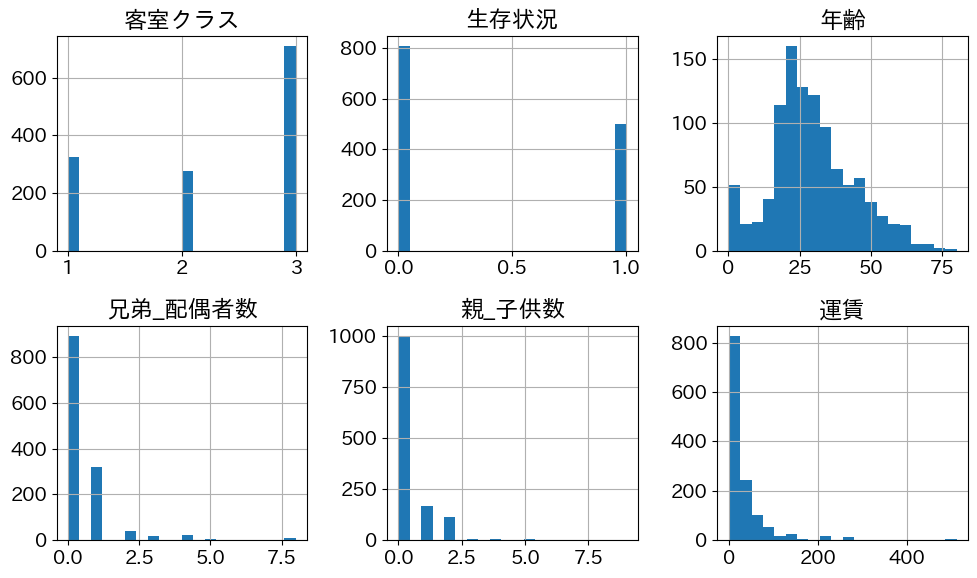

In [28]:
plt.rcParams['figure.figsize'] = (10, 6)

# データフレームの数値項目でヒストグラム表示　(3.5.2項)
df.hist(bins=20, layout=(2, 3))
plt.tight_layout()
plt.show()

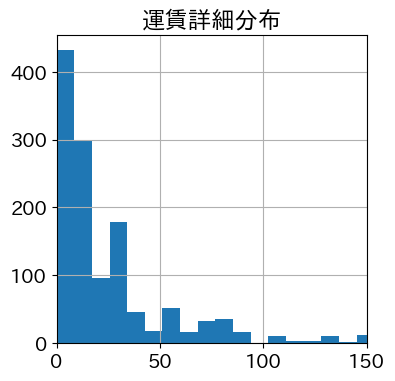

In [29]:
plt.rcParams['figure.figsize'] = (4, 4)

# 運賃の詳細分布
df['運賃'].hist(bins=60)
plt.xlim(0, 150)
plt.title('運賃詳細分布')
plt.show()

#### 非数値項目の度数分布

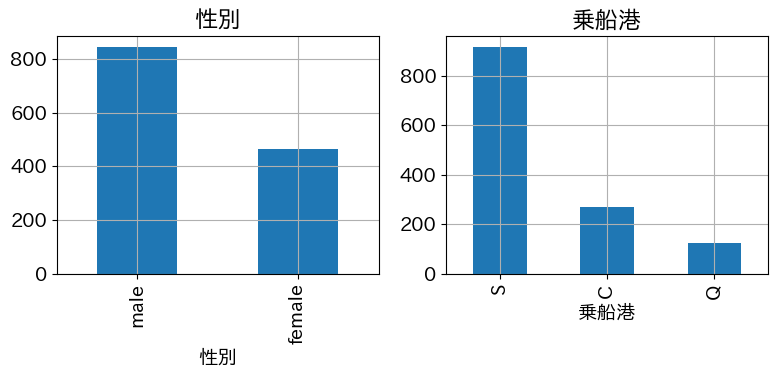

In [30]:
plt.rcParams['figure.figsize'] = (8, 4)

# 非数値項目の度数分布 (3.5.3項)
df2 = df[['性別', '乗船港']]

for i, c in enumerate(df2.columns):
    ax = plt.subplot(1, 2, i+1)
    df2[c].value_counts().plot(
        kind='bar', title=c, ax=ax)

# レイアウトの調整
plt.tight_layout()
plt.show()

### 箱ひげ図

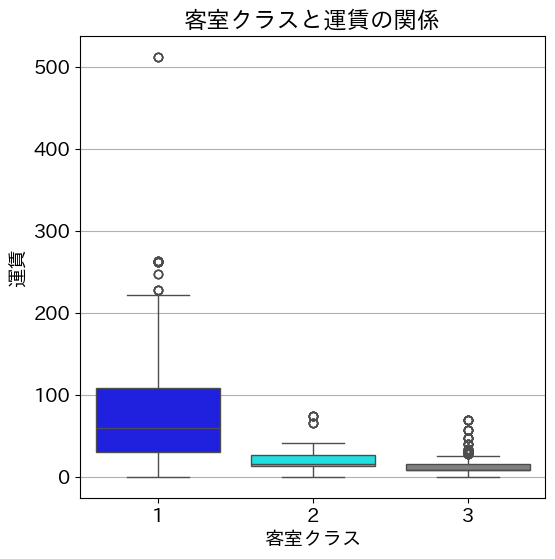

In [31]:
plt.rcParams['figure.figsize'] = (6, 6)

# 箱ひげ図の描画 (3.5.4項)
sns.boxplot(
    x='客室クラス', y='運賃', hue='客室クラス', data=df,
    palette=['blue', 'cyan', 'grey'], legend=False)
plt.title('客室クラスと運賃の関係')
plt.show()

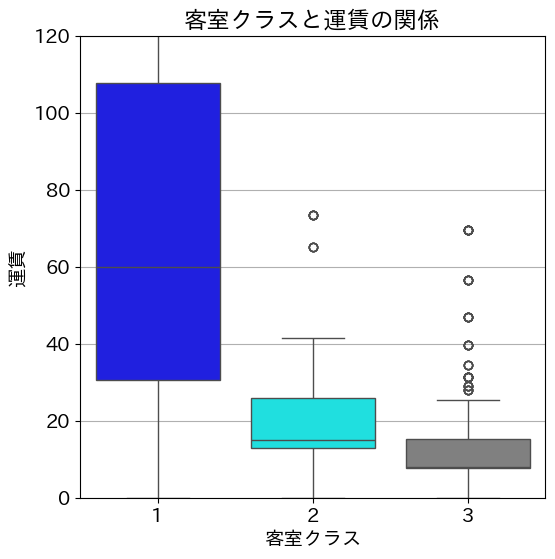

In [32]:
plt.rcParams['figure.figsize'] = (6, 6)

# 箱ひげ図の描画 (3.5.4項)
sns.boxplot(
    x='客室クラス', y='運賃', hue='客室クラス', data=df,
    palette=['blue', 'cyan', 'grey'], legend=False)
plt.title('客室クラスと運賃の関係')

# y軸の上限を120に変更する
plt.ylim(0, 120)
plt.show()

### ヒートマップ

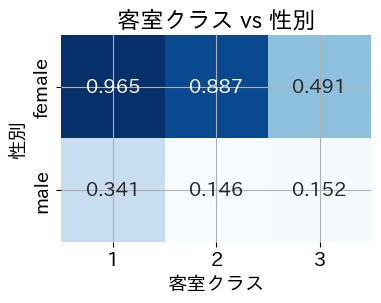

In [33]:
# 「性別」「客室クラス」を軸とした「生存状況」クロス集計の可視化
df_pivot = df.pivot_table(
    # 「性別」「客室クラス」の２軸で分析
    index='性別', columns='客室クラス',
    # 分析対象項目は「生存状況」　集約関数は「平均」
    values='生存状況', aggfunc='mean')

# ヒートマップ表示
plt.rcParams['figure.figsize'] = (4, 4)
sns.heatmap(
    df_pivot, square=True, annot=True,
    fmt='.03f', cmap='Blues', cbar=False)
xlabel = df_pivot.columns.name
ylabel = df_pivot.index.name
plt.title(xlabel + ' vs '+ylabel)
plt.xlabel(xlabel)
plt.ylabel(ylabel)
plt.show()

## 4.6 仮説と検証


### 生存状況と性別の関係

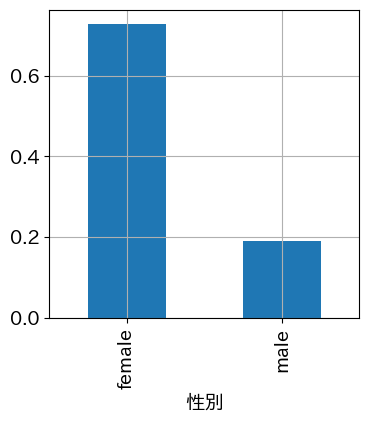

In [34]:
plt.rcParams['figure.figsize'] = (4, 4)

# 生存状況と性別の関係
df.groupby('性別')['生存状況'].mean().plot(kind='bar')
plt.show()

### 生存状況と年齢の関係

In [ ]:
plt.rcParams['figure.figsize'] = (8, 4)

# 生存状況と年齢の関係
sns.histplot(
    data=df,  x='年齢', hue='生存状況',
    palette=['blue', 'cyan'], multiple='dodge',
    shrink=0.7)
plt.show()

### 生存状況と客室クラスの関係

In [ ]:
plt.rcParams['figure.figsize'] = (4, 4)

# 生存状況と客室クラスの関係
df.groupby('客室クラス')['生存状況'].mean().plot(kind='bar')
plt.show()

### 生存状況と乗船港の関係

In [ ]:
plt.rcParams['figure.figsize'] = (4, 4)

# 生存状況と乗船港の関係
df.groupby('乗船港')['生存状況'].mean().plot(kind='bar')
plt.show()


### 乗船港で生存状況が異なる理由



In [ ]:
# 「客室クラス」「乗船港」を軸とした出現頻度分析
# 列を軸に正規化する
df_crosstab = pd.crosstab(
    index=df['客室クラス'],
    columns=df['乗船港'],
    normalize='columns')

# ヒートマップ表示
plt.rcParams['figure.figsize'] = (4, 4)
sns.heatmap(
    df_crosstab, square=True, annot=True,
    fmt='.03f', cmap='Blues', cbar=False)
plt.show()

## 4.7 深掘り分析

### 項目「救命ボート」の追加

In [ ]:
# 項目「救命ボード」を追加
df['救命ボート'] = df['救命ボート番号'].notnull()

# 結果確認
display(df[['救命ボート番号', '救命ボート']].head(3))

### 「救命ボード」「生存状況」を軸とした出現頻度分析

In [ ]:
# 「救命ボード」「生存状況」を軸とした出現頻度分析
df_crosstab = pd.crosstab(
    index=df['生存状況'],
    columns=df['救命ボート'])

# 結果確認
display(df_crosstab)

### 救命ボードなしで助かった人

In [ ]:
# 救命ボードなしで助かった人　(23名)
# queryメソッドを用いた深掘り分析(3.6.6項)
x1 = df.query(
    ' 生存状況 == 1 and 救命ボート == False ')

# 結果の一部確認
display(x1[[
    '客室クラス', '生存状況', '氏名', '性別', '年齢',
    '救命ボート番号']].head(3))

In [ ]:
# 救命ボートなしで助かった人の性別分布
print(x1['性別'].value_counts())
print()

# 救命ボートなしで助かった人の割合を性別に集計
x11 = df.query('救命ボート == False')
print(x11.groupby('性別')['生存状況'].mean())

### 救命ボードに乗れたのに助からなかった人

In [ ]:
# 救命ボードに乗れたのに助からなかった人　(9名)
# queryメソッドを用いた深掘り分析(3.6.6項)
x2 = df.query(
    ' 生存状況 == 0 and 救命ボート == True ')

# 結果の一部確認
display(x2[[
    '客室クラス', '生存状況', '氏名', '性別', '年齢',
    '救命ボート番号']].head(3))

In [ ]:
# 救命ボードに乗れたのに助からなかった人の性別分布
print(x2['性別'].value_counts())
print()

# 救命ボートに乗れたのに助からなかった人の割合を性別に集計
x22 = df.query('救命ボート == True')
print(1 - x22.groupby('性別')['生存状況'].mean())

### バージョンの確認

In [ ]:
!pip install watermark | tail -n 1
%load_ext watermark
%watermark --iversions